# Homework 2: Machine Learning for Regression

Dataset: 2026 Car Fuel Efficiency. Goal: predict `fuel_efficiency_mpg`.
Assignment: <https://github.com/bkget/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

COLUMNS = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]
TARGET = "fuel_efficiency_mpg"
FEATURES = [c for c in COLUMNS if c != TARGET]

df = pd.read_csv("../../data/car_fuel_efficiency_2026.csv")[COLUMNS]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA

Look at `fuel_efficiency_mpg`. Does it have a long tail?

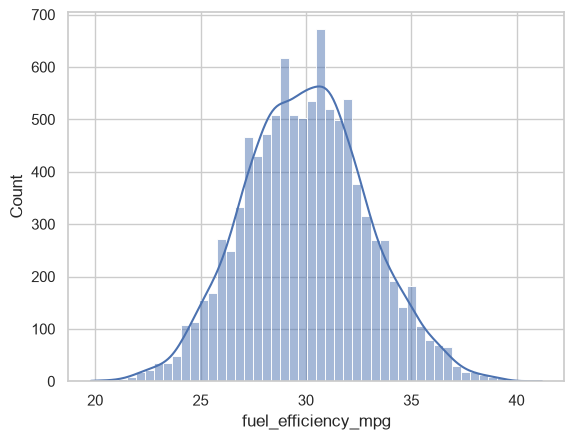

skewness: 0.081   mean: 30.00   median: 30.00


In [2]:
sns.histplot(df[TARGET], bins=50, kde=True)
plt.show()
print(f"skewness: {df[TARGET].skew():.3f}   mean: {df[TARGET].mean():.2f}   median: {df[TARGET].median():.2f}")

**Answer:** No. The distribution is symmetric/bell-shaped (skew ≈ 0.08, mean ≈ median ≈ 30) with no long tail.

### Question 1

There's one column with missing values. What is it?

* `engine_displacement`
* `horsepower`
* `vehicle_weight`
* `model_year`

In [3]:
missing = df.isna().sum()
print(missing)
print("Column with missing values:", missing[missing > 0].index.tolist())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64
Column with missing values: ['horsepower']


**Answer:** `horsepower` (877 missing values)

### Question 2

What's the median (50% percentile) for variable `horsepower`?

- 204
- 254
- 304
- 354

In [4]:
df["horsepower"].median()

np.float64(254.0)

**Answer:** `254`

### Prepare and split the dataset

In [5]:
def split_dataset(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def prepare_X(frame, fill_value=0.0):
    return frame[FEATURES].fillna(fill_value).to_numpy()


def train_linear_regression(X, y, r=0.0):
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T @ X + r * np.eye(X.shape[1])
    w = np.linalg.inv(XTX) @ X.T @ y
    return w[0], w[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


df_train, df_val, df_test = split_dataset(df, seed=42)
y_train, y_val, y_test = (d[TARGET].to_numpy() for d in (df_train, df_val, df_test))
print(len(df_train), len(df_val), len(df_test))

6000 2000 2000


### Question 3

Fill the missing values of the Q1 column with 0 or with the mean (computed on the **training** set only),
train an unregularised linear regression for each, and compare validation RMSE (3 decimals).

- With 0
- With mean
- Both are equally good

In [6]:
hp_mean = df_train["horsepower"].mean()
print(f"train mean of horsepower: {hp_mean:.4f}")

scores_q3 = {}
for name, fill in [("With 0", 0.0), ("With mean", hp_mean)]:
    w0, w = train_linear_regression(prepare_X(df_train, fill), y_train)
    scores_q3[name] = round(rmse(y_val, w0 + prepare_X(df_val, fill) @ w), 3)

print(scores_q3)

train mean of horsepower: 254.4634
{'With 0': np.float64(2.205), 'With mean': np.float64(2.202)}


**Answer:** `With mean` (validation RMSE 2.202 vs. 2.205 with 0)

### Question 4

Regularised linear regression, NAs filled with 0. Try `r` in `[0, 0.01, 0.1, 1, 5, 10, 100]`,
evaluate on validation with RMSE rounded to 4 decimals. Ties -> smallest `r`.

Options: 0 · 0.01 · 0.1 · 1 · 5 · 10 · 100

In [7]:
X_train, X_val = prepare_X(df_train, 0), prepare_X(df_val, 0)

scores_q4 = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r)
    scores_q4[r] = round(rmse(y_val, w0 + X_val @ w), 4)

for r, s in scores_q4.items():
    print(f"r={r:<6} RMSE={s}")

best_r = min(scores_q4, key=lambda r: (scores_q4[r], r))  # ties -> smallest r
print("\nBest r:", best_r)

r=0      RMSE=2.2053
r=0.01   RMSE=2.2058
r=0.1    RMSE=2.2241
r=1      RMSE=2.3492
r=5      RMSE=2.4094
r=10     RMSE=2.4195
r=100    RMSE=2.4292

Best r: 0


**Answer:** `0` (validation RMSE 2.2053; it only gets worse as `r` grows)

### Question 5

Try seeds `[0..9]`, 60/20/20 split each time, fill NAs with 0, no regularisation, collect validation RMSE.
What's the std of all scores (`np.std`, 3 decimals)?

- 0.006 · 0.016 · 0.029 · 0.036

In [8]:
scores_q5 = []
for seed in range(10):
    tr, va, _ = split_dataset(df, seed)
    w0, w = train_linear_regression(prepare_X(tr, 0), tr[TARGET].to_numpy())
    scores_q5.append(rmse(va[TARGET].to_numpy(), w0 + prepare_X(va, 0) @ w))

print(np.round(scores_q5, 4))
print("std:", round(np.std(scores_q5), 3))

[2.2392 2.2021 2.1634 2.2044 2.2019 2.2458 2.2697 2.1908 2.2166 2.207 ]
std: 0.029


**Answer:** `0.029`

### Question 6

Split with seed 9, combine train + validation, fill NAs with 0, train with `r=0.001`.
What's the RMSE on the test dataset?

- 0.236 · 2.236 · 22.10 · 221.0

In [9]:
tr, va, te = split_dataset(df, seed=9)
full_train = pd.concat([tr, va])

w0, w = train_linear_regression(prepare_X(full_train, 0), full_train[TARGET].to_numpy(), r=0.001)
test_rmse = rmse(te[TARGET].to_numpy(), w0 + prepare_X(te, 0) @ w)
print("test RMSE:", test_rmse, "->", round(test_rmse, 3))

test RMSE: 2.2358277471917636 -> 2.236


**Answer:** `2.236`

---

## Summary of answers

| # | Question | Answer |
|---|---|:---:|
| EDA | Long tail in `fuel_efficiency_mpg`? | No |
| 1 | Column with missing values | `horsepower` |
| 2 | Median horsepower | `254` |
| 3 | Better imputation | With mean (2.202 vs 2.205) |
| 4 | Best `r` | `0` |
| 5 | Std of RMSE across seeds | `0.029` |
| 6 | Test RMSE (seed 9, r=0.001) | `2.236` |